In [7]:
import numpy as np
from sklearn import mixture
#import torch
#import triton
#import triton.language as tl

np.random.seed(43)
#torch.manual_seed(42)

#DEVICE = triton.runtime.driver.active.get_active_torch_device()

In [8]:
n_components = 4
true_means = np.random.rand(n_components, 2) * 10
true_sigmas = np.array([np.eye(2) * (0.1 + 0.9 * np.random.rand()) for _ in range(n_components)])

n_samples = 50
X = np.zeros((0, 2))
sections = []
for i in range(n_components):
    X_i = np.random.multivariate_normal(mean=true_means[i], cov=true_sigmas[i], size=int(n_samples))
    sections.append(X_i)
X = np.vstack(sections)

In [9]:
from kmeans import KMeans
from warp_kmeans import WarpKMeans

kmeans_model = KMeans(n_clusters=n_components, max_iter=1000, verbose=True)
kmeans_model.fit(X)

warp_kmeans_model = WarpKMeans(n_clusters=n_components, max_iter=1000, verbose=True)
warp_kmeans_model.fit(X)

Iteration: 0: Progress: 2.5436478073842435
Iteration: 5: Progress: 0.0
Init took: 0.0s
Iteration: 0: Progress: 3.1387636864129576
Iteration: 5: Progress: 0.0


In [10]:
kmeans_model.centroids, warp_kmeans_model.centroids

(array([[5.71437541, 5.79460476],
        [1.30355022, 4.22132876],
        [7.24925482, 5.05818464],
        [3.16096721, 8.58104709]]),
 array([[1.512563 , 2.373116 ],
        [6.573908 , 5.3822103],
        [1.0973588, 6.123023 ],
        [3.1952937, 8.6147585]], dtype=float32))

In [11]:
true_means

array([[1.15054566, 6.09066539],
       [1.33390964, 2.4058962 ],
       [3.27139056, 8.59137491],
       [6.66090213, 5.41162212]])

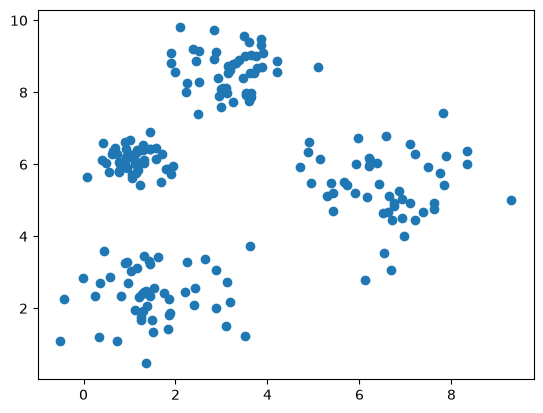

In [12]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])